In [ ]:
!pip install finesse

In [2]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

## **Coupled Cavity**

- **PRC** (PRM ↔ ITM) — the power recycling cavity
- **Arm** (ITM ↔ ETM) — the arm cavity

The two readouts:

- **REFL** — field at `PRM.p1.o`
- **POP**  — field at `PRM.p2.o`


## **Matrix construction**

The matrix is built column by column by perturbing one DOF at a time and
reading the slope of both detectors at that operating point:


$$
\begin{bmatrix} \text{POP} \\ \text{REFL} \end{bmatrix}
=
\begin{bmatrix} x_{11} & x_{12} \\ x_{21} & x_{22} \end{bmatrix}
\begin{bmatrix} \text{PRCL} \\ \text{ARM} \end{bmatrix}
$$

\
Expectation: $|x_{11}| \gg |x_{12}|$ and $|x_{22}| \gg |x_{21}|$,
since REFL and POP are each designed to be primarily sensitive to one DOF.

I have defined REFL --> ARM and POP --> PRCL

## **Fineese Model**

### **Cavity parameter**

* **PRM:** $R = 0.8999$, $T = 0.1001$
* **ITM:** $R = 0.991$, $T = 0.009$, $R_c = 11\text{ m}$
* **ETM:** $R = 0.9999$, $T = 0.0001$, $R_c = 13\text{ m}$
* **PRC Length:** $1.0\text{ m}$
* **Arm Cavity Length:** $5.0\text{ m}$

### **Selection of RF Modulation Frequency**

The RF modulation frequency is set for sideband resonance in the Power Recycling Cavity (PRC):

$$f_{\mathrm{RF}}=\left(n+\frac{1}{2}\right)\frac{c}{2L_{\mathrm{PRC}}}$$

* $c = 3 \times 10^8\ \text{m/s}$
* $L_{\mathrm{PRC}} = 1.0\ \text{m}$
* $n = 0$

Thus,
$$f_{\mathrm{RF}}=\left(\frac{1}{2}\right)\frac{3\times10^8}{\text{2}} = 75 \text{MHz}$$

$$3f = 3 \times f_{\mathrm{RF}} = 3 \times 75 = {225\ \text{MHz}}$$

### **Demodulation Phase**

- I first found the optimum demodulation phase for each detector.

- I tried to follow Approach 2 mentioned in the paper (Length Sensing and Control Schemes for a Three-Mirror Coupled Cavity). In this, I have scanned the demod phase from 0–360°. So the code chose the phase where the desired DoF has a large slope while the unwanted DoF has a small slope.

- I defined that POP is sensitive to PRCL and REFL to ARM.

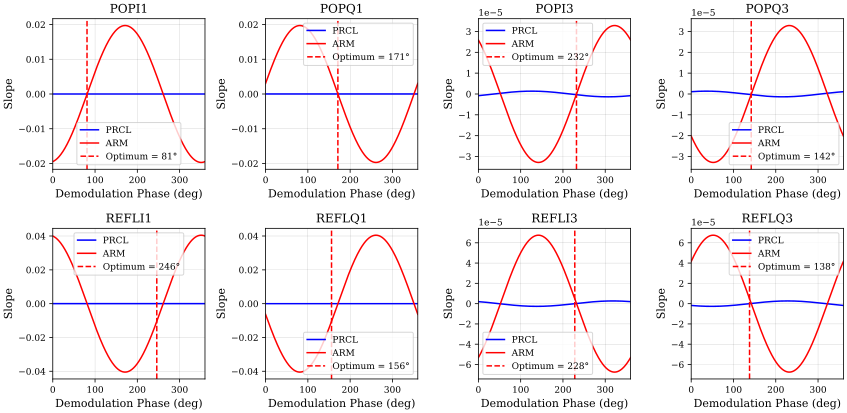

Optimum Demodulation Phases
POPI1    : 81°
POPQ1    : 171°
POPI3    : 232°
POPQ3    : 142°
REFLI1   : 246°
REFLQ1   : 156°
REFLI3   : 228°
REFLQ3   : 138°


In [3]:
#Base model for calculating the demod phase for optimising the POP and REFL detectors
def build_model(demod_phase):

    model = finesse.Model()
    model.parse(f"""

        l laser1 P=1 #Laser

        # RF Modulator
        s s1 laser1.p1 mod.p1 L=0.1
        modulator mod f=75M midx=0.1 order=3
        s s2 mod.p2 PRM.p1 L=0.1

        #3 mirror coupled cavity
        m PRM R=0.8999 T=0.1001 phi=0
        s s_prc PRM.p2 ITM.p1 L=1.0
        m ITM R=0.991 T=0.009 phi=0 Rc=11
        s s_arm ITM.p2 ETM.p1 L=5.0
        m ETM R=0.9999 T=0.0001 phi=0 Rc=13

        #Detectors for DC power
        pd Parm ITM.p2.o
        pd Pprc PRM.p2.o

        #For each RF frequency:
          # demod: in-phase modulation
          # demod + 90: quadrature phase modulation

        #POP detectors
        pd1 POPI1 PRM.p2.o 75M  {demod_phase}
        pd1 POPQ1 PRM.p2.o 75M  {demod_phase + 90}
        pd1 POPI3 PRM.p2.o 225M {demod_phase}
        pd1 POPQ3 PRM.p2.o 225M {demod_phase + 90}

        #REFL detectors
        pd1 REFLI1 PRM.p1.o 75M  {demod_phase}
        pd1 REFLQ1 PRM.p1.o 75M  {demod_phase + 90}
        pd1 REFLI3 PRM.p1.o 225M {demod_phase}
        pd1 REFLQ3 PRM.p1.o 225M {demod_phase + 90}

    """)
    return model

#In-phase and Quadrature components of POP and REFL
all_detectors = ["POPI1","POPQ1", "POPI3","POPQ3", "REFLI1","REFLQ1", "REFLI3","REFLQ3"]

#Scanning for demod phase (Approach 2)
#Defining operating point
PRM0 = 0
ETM0 = 0

# Calculating the slope near resonance
def calculate_slope(x, signal, window=5):

    centre = len(x) // 2
    #points used for linear fit
    x_fit = x[centre-window : centre+window+1]
    y_fit = signal[centre-window : centre+window+1]
    #Linear fit
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    return slope

#Scanning the phase from 0-360°
demod_phases = np.arange(0, 361, 1)

prcl_slopes = {det: [] for det in all_detectors} #storing d(signal)/d(PRCL) for every detector
arm_slopes  = {det: [] for det in all_detectors} #storing d(signal)/d(ARM) for every detector

#Optimisation Loop
for phase in demod_phases:
    model = build_model(phase)

    model.PRM.phi = PRM0
    model.ETM.phi = ETM0

#PRCL DoF
    out_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 - 0.01, PRM0 + 0.01, 200))
    x_prcl = out_prcl.x[0]
    centre_prcl = np.argmin(np.abs(x_prcl))

#ARM DoF
    out_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 - 0.01, ETM0 + 0.01, 200))
    x_arm = out_arm.x[0]
    centre_arm = np.argmin(np.abs(x_arm))


    for detector in all_detectors:

        slope_prcl = calculate_slope(x_prcl, out_prcl[detector]) #d(signal)/d(PRCL)
        slope_arm = calculate_slope(x_arm, out_arm[detector]) #d(signal)/d(ARM)

        prcl_slopes[detector].append(slope_prcl)
        arm_slopes[detector].append(slope_arm)

for detector in all_detectors:
    prcl_slopes[detector] = np.asarray(prcl_slopes[detector])
    arm_slopes[detector]  = np.asarray(arm_slopes[detector])


#Optimum demod phase
best_phase = {}

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, detector in enumerate(all_detectors):

    # Signed slopes (for plotting)
    prcl = prcl_slopes[detector]
    arm = arm_slopes[detector]

    # Optimisation of detector sensitivity
    if detector.startswith("POP"):
        ratio = np.abs(prcl) / (np.abs(arm) + 1e-12) #POP --> PRCL
    else:
        ratio = np.abs(arm) / (np.abs(prcl) + 1e-12) #REFL --> ARM

    optimum = np.argmax(ratio) #Best demod phase
    best_phase[detector] = demod_phases[optimum]

    # Plotting
    ax = axes[i]

    ax.plot(demod_phases, prcl, label="PRCL")
    ax.plot(demod_phases, arm, label="ARM")

    ax.axvline(demod_phases[optimum], color="red", linestyle="--", label=f"Optimum = {demod_phases[optimum]}°")

    ax.set_title(detector)
    ax.set_xlabel("Demodulation Phase (deg)")
    ax.set_ylabel("Slope")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print("Optimum Demodulation Phases")
for detector in all_detectors:
    print(f"{detector:8s} : {best_phase[detector]}°")

- The plots show how detector sensitivity changes as the demodulation phase varies. Because varying the demodulation phase rotates the signal between its in-phase ($I$) and quadrature ($Q$) components, the sensitivities vary sinusoidally over a full 360° scan.

- For each plot, blue curve corresponds to sensitivity wrt PRCL and red curve to ARM. The demod phase is chosen such that the desired DoF produces a strong response, and the unwanted DoF produces a small response.


- In the plots of POPI1, POPQ1 ,REFLI1 and REFLQ1, the blue curves are almost flat. This might indicate that these detectors are very little sensitive to PRCL.

### **Sensing Matrix Construction**

I fixed the operating point and scanned the PRCL and ARM degrees of freedom independently.

For each of the eight demodulated detectors (POPI, POPQ, REFLI, REFLQ at 1f and 3f), I fitted a linear region near resonance using `np.polyfit` to get response slopes:

$$\frac{d(\text{detector})}{d(\text{PRCL})} \quad\text{and}\quad \frac{d(\text{detector})}{d(\text{ARM})}$$

I chose the best sensors by maximizing the separation ratios.


In [4]:
def build_model():
    model = finesse.Model()
    model.parse(f"""

        l laser1 P=1 #Laser

        # RF Phase Modulator
        s s1 laser1.p1 mod.p1 L=0.1
        modulator mod f=75M midx=0.1 order=3
        s s2 mod.p2 PRM.p1 L=0.1

        #3 mirror coupled cavity
        m PRM R=0.8999 T=0.1001 phi=0
        s s_prc PRM.p2 ITM.p1 L=1.0
        m ITM R=0.991 T=0.009 phi=0 Rc=11
        s s_arm ITM.p2 ETM.p1 L=5.0
        m ETM R=0.9999 T=0.0001 phi=0 Rc=13

        #Detectors for DC power
        pd Parm ITM.p2.o
        pd Pprc PRM.p2.o

        #POP detectors with the optimum demodulation phases
        pd1 POPI1 PRM.p2.o 75M  {best_phase["POPI1"]}
        pd1 POPQ1 PRM.p2.o 75M  {best_phase["POPQ1"]}
        pd1 POPI3 PRM.p2.o 225M {best_phase["POPI3"]}
        pd1 POPQ3 PRM.p2.o 225M {best_phase["POPQ3"]}

        #REFL detectors with the optimum demodulation phases
        pd1 REFLI1 PRM.p1.o 75M  {best_phase["REFLI1"]}
        pd1 REFLQ1 PRM.p1.o 75M  {best_phase["REFLQ1"]}
        pd1 REFLI3 PRM.p1.o 225M {best_phase["REFLI3"]}
        pd1 REFLQ3 PRM.p1.o 225M {best_phase["REFLQ3"]}

    """)
    return model

In [5]:
wavelength = 1064e-9
#Converting the mirror sweep from ° to m
deg_to_m = wavelength / 360.0

#8 detectors present at two porst
PORTS = [ "POPI1","POPQ1", "POPI3","POPQ3", "REFLI1","REFLQ1", "REFLI3","REFLQ3"]

#Operating point
PRM0 = 0
ETM0 = 0

model = build_model()
model.PRM.phi = PRM0
model.ETM.phi = ETM0

#ARM DoF
out_arm = model.run(Xaxis("ETM.phi", "lin", ETM0 - 0.01, ETM0 + 0.01, 200))
x_arm = (out_arm.x[0]-ETM0) * deg_to_m

#PRCL DoF
out_prcl = model.run(Xaxis("PRM.phi", "lin", PRM0 - 0.01, PRM0 + 0.01, 200))
x_prcl = (out_prcl.x[0]-PRM0) * deg_to_m


#Calculating the slope near resonance
def calculate_slope(x, signal, window=5):

    centre = len(x)//2
    #Points used for Linear fit
    x_fit = x[centre-window : centre+window+1]
    y_fit = signal[centre-window : centre+window+1]
    slope, intercept = np.polyfit(x_fit, y_fit, 1) #Linear fit
    return slope

#Calculating the response of the detectors [d(detector) / d(PRCL) & d(detector) / d(ARM)]
arm_column = [
calculate_slope(x_arm, out_arm[port])
    for port in PORTS
]

prcl_column = [
    calculate_slope(x_prcl, out_prcl[port])
    for port in PORTS
]


#Finding the best POP and REFL detector

#POP detector with the highest PRCL-to-ARM sensitivity ratio
best_pop = None
best_pop_ratio = 0

for port in ["POPI1","POPQ1", "POPI3","POPQ3"]:

    i = PORTS.index(port)
    ratio = abs(prcl_column[i]) / (abs(arm_column[i]) + 1e-20)
    if ratio > best_pop_ratio:
        best_pop_ratio = ratio
        best_pop = port

#REFL detector with the highest PRCL-to-ARM sensitivity ratio
best_refl = None
best_refl_ratio = 0

for port in [ "REFLI1","REFLQ1", "REFLI3","REFLQ3"]:
    i = PORTS.index(port)
    ratio = abs(arm_column[i]) / (abs(prcl_column[i]) + 1e-20)
    if ratio > best_refl_ratio:
        best_refl_ratio = ratio
        best_refl = port

print(f"Best POP detector: {best_pop}")
print(f"Best REFL detector: {best_refl}")


#Sensing Matrix
i_pop = PORTS.index(best_pop)
i_refl = PORTS.index(best_refl)

M = np.array([
    [prcl_column[i_pop],  arm_column[i_pop]],
    [prcl_column[i_refl], arm_column[i_refl]]
])


print("The sensing matrix obtained is:")
print(f"{'':12s}{'PRCL':>15s}{'ARM':>15s}")
print(f"{best_pop:12s}{M[0,0]:15.5e}{M[0,1]:15.5e}")
print(f"{best_refl:12s}{M[1,0]:15.5e}{M[1,1]:15.5e}")


Best POP detector: POPI3
Best REFL detector: REFLI1
The sensing matrix obtained is:
                       PRCL            ARM
POPI3          -1.22795e+02   -1.55854e+01
REFLI1         -2.69336e+00   -3.54754e+06


- From optimising, POPI3 is the best detector for sensing PRCL and REFLI1 is best for ARM.
- The sensing matrix obtained is:

\begin{bmatrix}
-1.22\times10^{2} & -1.55\times10^{1} \\
-2.69 & -3.54\times10^{6}
\end{bmatrix}


- For an ideal sensing matrix, we require:

$$|x_{11}| \gg |x_{12}| \quad \text{and} \quad |x_{22}| \gg |x_{21}|$$

  This ensures that each detector responds to its target DoF.

- POPI3: $$|x_{11}| = 1.22 \times 10^{2} \gg |x_{12}| = 1.55 \times 10^{1}$$

- REFLI1: $$|x_{22}| = 3.54 \times 10^{6} \gg |x_{21}| = 2.69$$

- The matrix is diagonally dominant with small off-diagonal coupling.

### **Error Signal Plots**

I plotted the corresponding error signals to verify their behaviour.

I fitted a linear region using `np.polyfit` onto the detector response (POP and REFL that is used in sensing matrix) to verify that the detectors are nearly linear near the operating point!

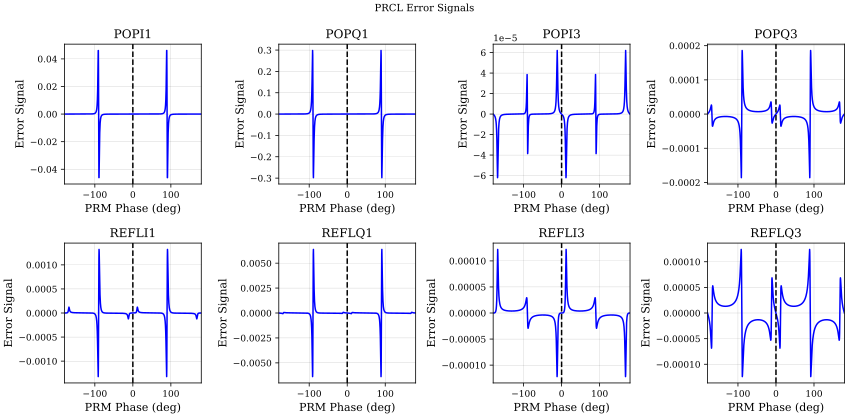

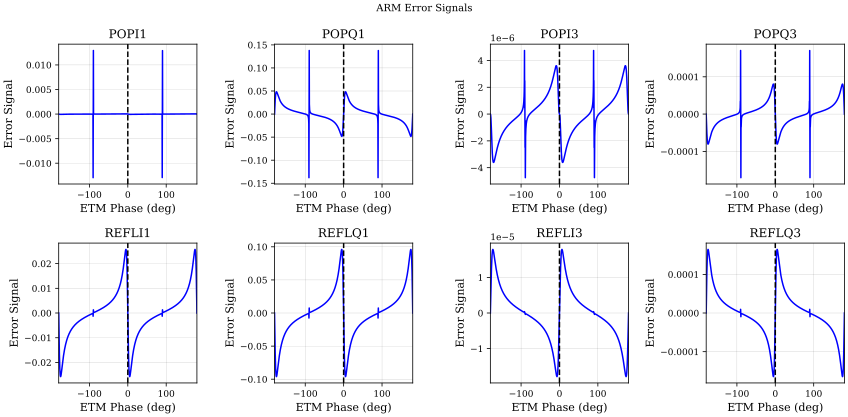

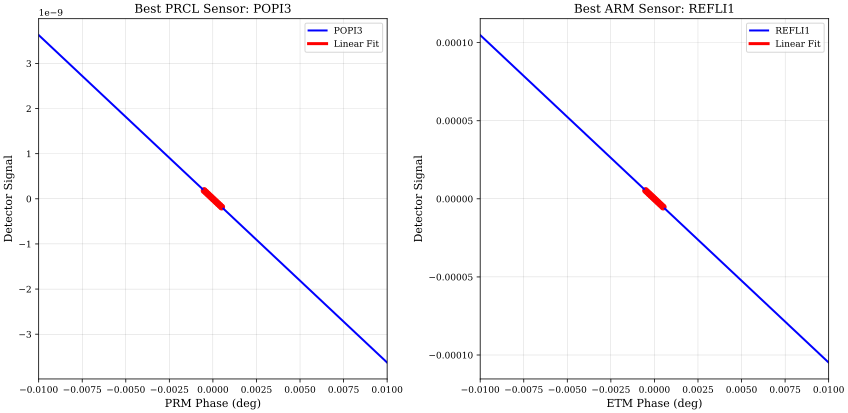

In [6]:
model = build_model()

wide_prcl = model.run(Xaxis("PRM.phi", "lin", -180, 180, 1000))
wide_arm = model.run(Xaxis("ETM.phi", "lin", -180, 180, 1000))

#Plotting the full error signal for PRCL DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_prcl.x[0], wide_prcl[port])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("PRM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("PRCL Error Signals")
plt.tight_layout()
plt.show()

#Plotting the full error signal for ARM DoF
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for ax, port in zip(axes.flatten(), PORTS):
    ax.plot(wide_arm.x[0], wide_arm[port])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(port)
    ax.set_xlabel("ETM Phase (deg)")
    ax.set_ylabel("Error Signal")
    ax.grid(True)
plt.suptitle("ARM Error Signals")
plt.tight_layout()
plt.show()


#Plotting the linear fit for the best POP and REFL channel used in our sensing matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#PRCL
ax = axes[0]
ax.plot(out_prcl.x[0], out_prcl[best_pop], linewidth=2,label=best_pop)
## Select points around the operating point for the linear fit
centre = len(out_prcl.x[0]) // 2
window = 5
xfit = out_prcl.x[0][centre-window:centre+window+1]
yfit = out_prcl[best_pop][centre-window:centre+window+1]
slope, intercept = np.polyfit(xfit, yfit, 1)

ax.plot(xfit, slope*xfit + intercept,'r',linewidth=3, label="Linear Fit")
ax.scatter(xfit, yfit, color="red")
ax.set_title(f"Best PRCL Sensor: {best_pop}")
ax.set_xlabel("PRM Phase (deg)")
ax.set_ylabel("Detector Signal")
ax.grid(True)
ax.legend()


#ARM
ax = axes[1]
ax.plot(out_arm.x[0], out_arm[best_refl],linewidth=2,label=best_refl)
xfit = out_arm.x[0][centre-window:centre+window+1]
yfit = out_arm[best_refl][centre-window:centre+window+1]
slope, intercept = np.polyfit(xfit, yfit, 1)

ax.plot(xfit, slope*xfit + intercept,'r', linewidth=3, label="Linear Fit")
ax.scatter(xfit, yfit, color="red")
ax.set_title(f"Best ARM Sensor: {best_refl}")
ax.set_xlabel("ETM Phase (deg)")
ax.set_ylabel("Detector Signal")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()
